In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns       
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
from io import StringIO

In [2]:
import json
import re
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. PARSE run.log INTO A SINGLE DATAFRAME
# =========================================================
def parse_run_log_original_style(path: str) -> pd.DataFrame:
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        raw = f.read()

    # your original regex-style split of top-level JSON objects
    objects = re.findall(r'\{.*?\}(?=\s*\{|\s*$)', raw, flags=re.DOTALL)

    for obj_text in objects:
        try:
            outer = json.loads(obj_text)
        except json.JSONDecodeError:
            continue

        ts = outer.get("timestamp")
        lambda_log = outer.get("lambdaLog", "")
        if not lambda_log:
            continue

        try:
            inner = json.loads(lambda_log)
        except json.JSONDecodeError:
            continue

        # expected:
        # inner = [state, orders, conversions, trader_data, logs]
        if not isinstance(inner, list) or len(inner) < 5:
            continue

        state = inner[0]
        submitted_orders = inner[1]
        conversions = inner[2]
        trader_data = inner[3]
        text_logs = inner[4]

        # expected state layout:
        # [timestamp, trader_data, listings, order_depths, own_trades, market_trades, position, observations]
        positions = state[6] if isinstance(state, list) and len(state) > 6 else {}

        # -------------------------------------------------
        # submitted order rows
        # -------------------------------------------------
        if isinstance(submitted_orders, list):
            for order in submitted_orders:
                if not isinstance(order, list) or len(order) != 3:
                    continue

                sym, price, qty = order

                rows.append({
                    "timestamp": ts,
                    "symbol": sym,
                    "kind": "submitted_order",
                    "price": price,
                    "qty": qty,
                    "side": "buy" if qty > 0 else "sell",
                    "position": positions.get(sym) if isinstance(positions, dict) else pd.NA,
                    "log_text": text_logs,
                    "raw_line": pd.NA,
                    "fair": pd.NA,
                    "trend": pd.NA,
                    "signal": pd.NA,
                    "regime": pd.NA,
                    "buy_used": pd.NA,
                    "sell_used": pd.NA,
                })

        # -------------------------------------------------
        # summary rows from text logs
        # -------------------------------------------------
        if isinstance(text_logs, str):
            for line in text_logs.splitlines():
                line = line.strip()
                if not line:
                    continue

                # Example formats:
                # OSMIUM pos=0 fair=10002.422 buy_used=15 sell_used=15 orders=[...]
                # ROOT pos=-5 fair=11999.962 trend=0.12 signal=0.12 regime=neutral ...

                m = re.match(r'^(OSMIUM|ROOT)\s+pos=([-]?\d+)\s+fair=([0-9.]+)', line)
                if not m:
                    continue

                label = m.group(1)
                sym = "ASH_COATED_OSMIUM" if label == "OSMIUM" else "INTARIAN_PEPPER_ROOT"

                row = {
                    "timestamp": ts,
                    "symbol": sym,
                    "kind": "summary",
                    "price": pd.NA,
                    "qty": pd.NA,
                    "side": pd.NA,
                    "position": int(m.group(2)),
                    "fair": float(m.group(3)),
                    "trend": pd.NA,
                    "signal": pd.NA,
                    "regime": pd.NA,
                    "buy_used": pd.NA,
                    "sell_used": pd.NA,
                    "log_text": text_logs,
                    "raw_line": line,
                }

                trend_m = re.search(r'trend=([-]?[0-9.]+)', line)
                signal_m = re.search(r'signal=([-]?[0-9.]+)', line)
                regime_m = re.search(r'regime=([A-Za-z_]+)', line)
                buy_used_m = re.search(r'buy_used=(\d+)', line)
                sell_used_m = re.search(r'sell_used=(\d+)', line)

                if trend_m:
                    row["trend"] = float(trend_m.group(1))
                if signal_m:
                    row["signal"] = float(signal_m.group(1))
                if regime_m:
                    row["regime"] = regime_m.group(1)
                if buy_used_m:
                    row["buy_used"] = int(buy_used_m.group(1))
                if sell_used_m:
                    row["sell_used"] = int(sell_used_m.group(1))

                rows.append(row)

    df = pd.DataFrame(rows)

    # -------------------------------------------------
    # stable schema so downstream code stops whining
    # -------------------------------------------------
    expected_cols = [
        "timestamp", "symbol", "kind", "price", "qty", "side", "position",
        "fair", "trend", "signal", "regime", "buy_used", "sell_used",
        "log_text", "raw_line"
    ]

    for col in expected_cols:
        if col not in df.columns:
            df[col] = pd.NA

    # numeric cleanup
    numeric_cols = [
        "timestamp", "price", "qty", "position",
        "fair", "trend", "signal", "buy_used", "sell_used"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[expected_cols].sort_values(["timestamp", "symbol", "kind"]).reset_index(drop=True)
    return df

df shape: (16417, 15)
kind
submitted_order    16417
Name: count, dtype: int64
   timestamp             symbol             kind  price  qty  side  position  fair  trend  signal regime  buy_used  sell_used                                                                                                                                                                                                                                    log_text raw_line
0          0  ASH_COATED_OSMIUM  submitted_order   9996    8   buy       NaN   NaN    NaN     NaN   <NA>       NaN        NaN                                                                             {"ema_fast":{},"ema_slow":{},"price_hist":{"ASH_COATED_OSMIUM":[10013.0,10013.0]},"osmium_fair":{"last_fair":10003.9},"root_centre":{},"root_regime":"neutral"}     <NA>
1          0  ASH_COATED_OSMIUM  submitted_order  10004   -8  sell       NaN   NaN    NaN     NaN   <NA>       NaN        NaN                                                       

C:\Users\joven\AppData\Local\Temp\ipykernel_13412\2031516288.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


No overlapping quote/market rows for INTARIAN_PEPPER_ROOT in this window


C:\Users\joven\AppData\Local\Temp\ipykernel_13412\2031516288.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


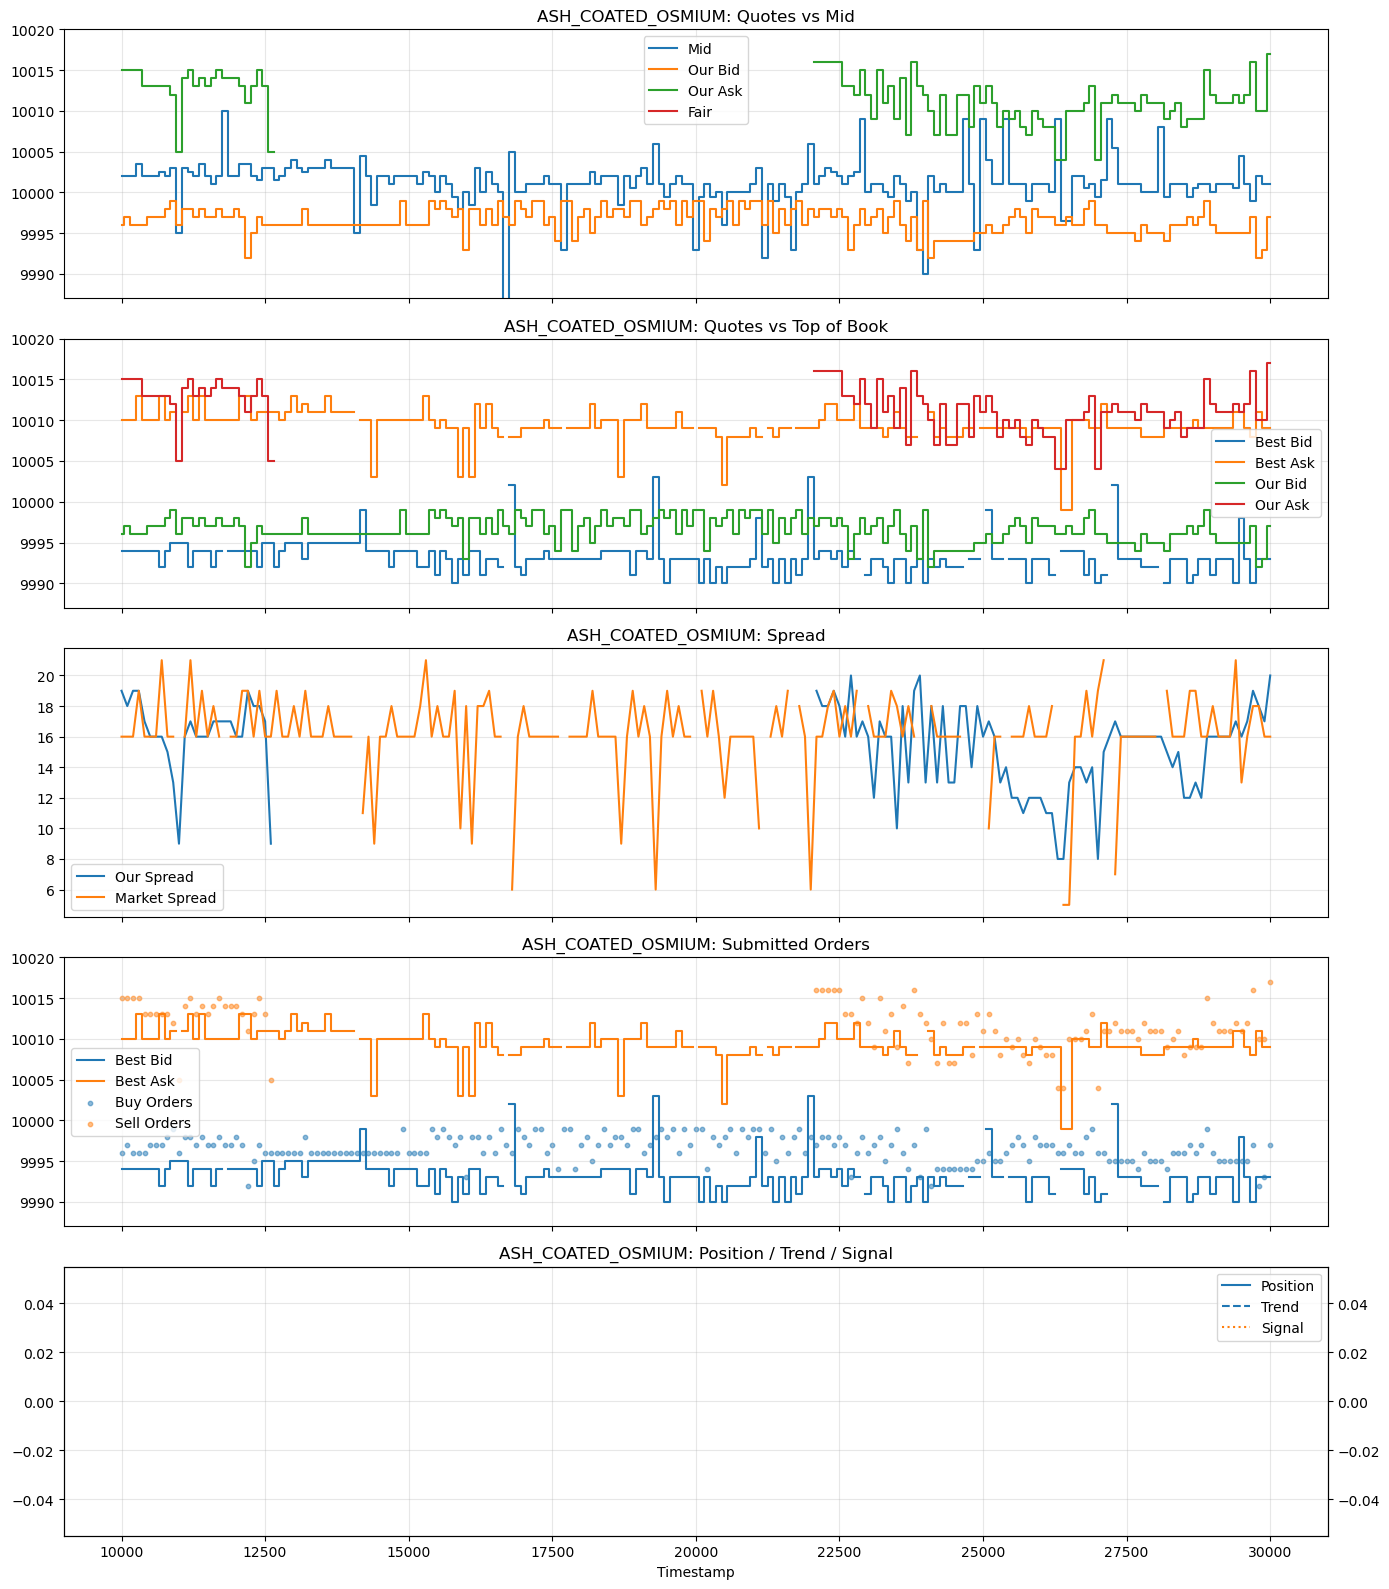

In [3]:
# =========================================================
# 2. BUILD PER-TIMESTAMP QUOTE TABLE
# =========================================================
def build_quotes_table(df_orders: pd.DataFrame) -> pd.DataFrame:
    quotes = (
        df_orders
        .groupby(["timestamp", "symbol"], group_keys=False)
        .apply(lambda g: pd.Series({
            "our_bid": g.loc[g["qty"] > 0, "price"].max() if (g["qty"] > 0).any() else None,
            "our_ask": g.loc[g["qty"] < 0, "price"].min() if (g["qty"] < 0).any() else None,
            "bid_size": g.loc[g["qty"] > 0, "qty"].sum() if (g["qty"] > 0).any() else 0,
            "ask_size": -g.loc[g["qty"] < 0, "qty"].sum() if (g["qty"] < 0).any() else 0,
        }))
        .reset_index()
    )
    quotes["our_spread"] = quotes["our_ask"] - quotes["our_bid"]
    return quotes


# =========================================================
# 3. PLOTTING FUNCTION
# =========================================================
def plot_mm_clean(
    symbol,
    df_orders,
    market_df,
    summary_df=None,
    tolerance=100,
    start_ts=None,
    end_ts=None
):
    q = build_quotes_table(df_orders)
    q = q[q["symbol"] == symbol].copy()
    m = market_df[market_df["product"] == symbol].copy()

    # ensure numeric timestamps
    q["timestamp"] = pd.to_numeric(q["timestamp"], errors="coerce")
    m["timestamp"] = pd.to_numeric(m["timestamp"], errors="coerce")

    # early filtering
    if start_ts is not None:
        q = q[q["timestamp"] >= start_ts]
        m = m[m["timestamp"] >= start_ts]
    if end_ts is not None:
        q = q[q["timestamp"] <= end_ts]
        m = m[m["timestamp"] <= end_ts]

    q = q.sort_values("timestamp")
    m = m.sort_values("timestamp")

    # merge market with our quotes
    plot_df = pd.merge_asof(
        m,
        q,
        on="timestamp",
        direction="nearest",
        tolerance=tolerance
    )

    plot_df = plot_df.dropna(subset=["our_bid", "our_ask"], how="all").copy()

    # post-merge sanity filter
    if start_ts is not None:
        plot_df = plot_df[plot_df["timestamp"] >= start_ts]
    if end_ts is not None:
        plot_df = plot_df[plot_df["timestamp"] <= end_ts]

    if plot_df.empty:
        print(f"No overlapping quote/market rows for {symbol} in this window")
        return None

    # -------------------------------------------------
    # summary merge, but only using columns that exist
    # -------------------------------------------------
    if summary_df is not None:
        s = summary_df[summary_df["symbol"] == symbol].copy()
        s["timestamp"] = pd.to_numeric(s["timestamp"], errors="coerce")

        if start_ts is not None:
            s = s[s["timestamp"] >= start_ts]
        if end_ts is not None:
            s = s[s["timestamp"] <= end_ts]

        s = s.sort_values("timestamp")

        wanted = ["timestamp", "position", "fair", "trend", "signal"]
        available = [c for c in wanted if c in s.columns]

        if len(available) > 1:
            plot_df = pd.merge_asof(
                plot_df.sort_values("timestamp"),
                s[available].sort_values("timestamp"),
                on="timestamp",
                direction="nearest",
                tolerance=tolerance
            )

    # orders for scatter plot
    orders_sym = df_orders[df_orders["symbol"] == symbol].copy()
    orders_sym["timestamp"] = pd.to_numeric(orders_sym["timestamp"], errors="coerce")

    if start_ts is not None:
        orders_sym = orders_sym[orders_sym["timestamp"] >= start_ts]
    if end_ts is not None:
        orders_sym = orders_sym[orders_sym["timestamp"] <= end_ts]

    bids = orders_sym[orders_sym["qty"] > 0]
    asks = orders_sym[orders_sym["qty"] < 0]

    # y-axis zoom
    ymin = min(
        plot_df["bid_price_1"].min(),
        plot_df["our_bid"].min(skipna=True),
        plot_df["our_ask"].min(skipna=True),
    ) - 3

    ymax = max(
        plot_df["ask_price_1"].max(),
        plot_df["our_bid"].max(skipna=True),
        plot_df["our_ask"].max(skipna=True),
    ) + 3

    n_axes = 5 if summary_df is not None else 4
    fig, axes = plt.subplots(n_axes, 1, figsize=(14, 16), sharex=True)

    # 1. quotes vs mid
    ax = axes[0]
    ax.step(plot_df["timestamp"], plot_df["mid_price"], where="mid", label="Mid")
    ax.step(plot_df["timestamp"], plot_df["our_bid"], where="mid", label="Our Bid")
    ax.step(plot_df["timestamp"], plot_df["our_ask"], where="mid", label="Our Ask")
    if "fair" in plot_df.columns:
        ax.step(plot_df["timestamp"], plot_df["fair"], where="mid", label="Fair")
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"{symbol}: Quotes vs Mid")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. quotes vs top of book
    ax = axes[1]
    ax.step(plot_df["timestamp"], plot_df["bid_price_1"], where="mid", label="Best Bid")
    ax.step(plot_df["timestamp"], plot_df["ask_price_1"], where="mid", label="Best Ask")
    ax.step(plot_df["timestamp"], plot_df["our_bid"], where="mid", label="Our Bid")
    ax.step(plot_df["timestamp"], plot_df["our_ask"], where="mid", label="Our Ask")
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"{symbol}: Quotes vs Top of Book")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. spread
    ax = axes[2]
    ax.plot(plot_df["timestamp"], plot_df["our_spread"], label="Our Spread")
    ax.plot(plot_df["timestamp"], plot_df["ask_price_1"] - plot_df["bid_price_1"], label="Market Spread")
    ax.set_title(f"{symbol}: Spread")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. submitted orders
    ax = axes[3]
    ax.step(plot_df["timestamp"], plot_df["bid_price_1"], where="mid", label="Best Bid")
    ax.step(plot_df["timestamp"], plot_df["ask_price_1"], where="mid", label="Best Ask")
    ax.scatter(bids["timestamp"], bids["price"], s=10, alpha=0.5, label="Buy Orders")
    ax.scatter(asks["timestamp"], asks["price"], s=10, alpha=0.5, label="Sell Orders")
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"{symbol}: Submitted Orders")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 5. position / trend / signal
    if summary_df is not None:
        ax = axes[4]
        if "position" in plot_df.columns:
            ax.plot(plot_df["timestamp"], plot_df["position"], label="Position")

        ax2 = ax.twinx()
        if "trend" in plot_df.columns:
            ax2.plot(plot_df["timestamp"], plot_df["trend"], linestyle="--", label="Trend")
        if "signal" in plot_df.columns:
            ax2.plot(plot_df["timestamp"], plot_df["signal"], linestyle=":", label="Signal")

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2)
        ax.set_title(f"{symbol}: Position / Trend / Signal")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

    return plot_df


# =========================================================
# 4. LOAD EVERYTHING AND RUN
# =========================================================
# Parse run.log
df = parse_run_log_original_style(
    r"C:\Users\joven\Documents\ML Projects\IMC-Prosperity-4\run2.log"
)

print("df shape:", df.shape)
print(df["kind"].value_counts(dropna=False))
print(df.head(10).to_string())

# Split tables
df_orders = df[df["kind"] == "submitted_order"].copy()
summary_df = df[df["kind"] == "summary"].copy()

# Load market data from prosperity json
with open(
    r"C:/Users/joven/Documents/ML Projects/IMC-Prosperity-4/Round_1/CSV Data/150789.json",
    "r",
    encoding="utf-8"
) as f:
    result_json = json.load(f)

market_df = pd.read_csv(StringIO(result_json["activitiesLog"]), sep=";")

# Plot ROOT
root_plot_df = plot_mm_clean(
    "INTARIAN_PEPPER_ROOT",
    df_orders=df_orders,
    market_df=market_df,
    summary_df=summary_df,
    tolerance=100,
    start_ts=10000,
    end_ts=30000
)

# Plot OSMIUM
osmium_plot_df = plot_mm_clean(
    "ASH_COATED_OSMIUM",
    df_orders=df_orders,
    market_df=market_df,
    summary_df=summary_df,
    tolerance=100,
    start_ts=10000,
    end_ts=30000
)
